In [1]:
import pandas as pd
import numpy as np

csv_filename = "data/data.csv"

# provera da ispravno pravimo data.csv fajl od polaznih fajlova koji predstavljaju dataset kako bi olaksali upotrebu i manipulaciju dataset-om
df = pd.read_csv(csv_filename)
print(df.head())

print("Provera broja NaN/null vrednosti:")
print(df.isna().sum().sum())

print("Provera broja inf vrednosti za numericke atribute:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Provera broja redova i kolona: ")
print(df.shape)

print("Provera broja subjekata i balansiranosti podataka po subjektu: ")
print(df[["subject_id", "target"]].value_counts())

print("Provera balansiranosti klasa: ")
print(df["target"].value_counts())

print("Provera broja atributa po vrsti merenja:")
print(f"ECG: {df.columns.str.startswith("ECG").sum()}")
print(f"TIB: {df.columns.str.startswith("IT").sum()}")
print(f"EDA arm: {df.columns.str.startswith("EDA_Arm").sum()}")
print(f"EDA hand: {df.columns.str.startswith("EDA_Hand").sum()}")

   subject_id  ECG_original_mean  ECG_original_std  ECG_original_trimmean25  \
0           1          -0.004125          0.254095                 0.001426   
1           1           0.031029          0.193761                 0.012918   
2           1           0.015678          0.182336                -0.003028   
3           1           0.014525          0.176636                -0.006161   
4           1           0.010349          0.179248                -0.008526   

   ECG_original_median  ECG_original_skewness  ECG_original_kurtosis  \
0             -0.01037              -0.538509                5.95534   
1             -0.00237               0.781415                5.18794   
2             -0.02337               0.881194                5.66530   
3             -0.02737               1.024900                6.10968   
4             -0.02737               0.935697                5.83902   

   ECG_original_max  ECG_original_min  ECG_original_prctile25  ...  \
0           1.04063   

In [2]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df.drop(columns=["subject_id", "target"])
y = df["target"]
groups = df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Dimenzije trening skupa: ", X_train.shape, y_train.shape)
print("Dimenzije test skupa: ", X_test.shape, y_test.shape)

print("Provera da se subjekti ne preklapaju izmedju trening i test skupa: ")
print("Broj zajednickih subjekata: ", len(set(groups_train) & set(groups_test)))
print("Broj subjekata u trening skupu: ", groups_train.nunique())
print("Broj subjekata u test skupu: ", groups_test.nunique())
print("Subjekti u test skupu: ", sorted(set(groups_test)))

print("Provera da su svi redovi svakog subjekta ostali na istoj strani podele: ")
print(all(groups_train.value_counts() == 112) and all(groups_test.value_counts() == 112))

print("Provera balansiranosti klasa u trening skupu: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Provera balansiranosti klasa u test skupu: ")
print(y_test.value_counts(normalize=True).sort_index())

# Normalizuje podatke grupisane po subjektu kako bi izbacili sum subjekta i prepoznavali aktivnosti samo na osnovu apsolutnih vrednosti atributa (ublazili uticaj subjekta)
# Mozemo da odmah izvrsimo i normalizaciju test podataka, zato sto je ova standardizacija po subjektu, i gleda samo redove grupisane po subjektu, pa nema curenja informacija iz testa
# koje mogu da dovedu do preprilagodjavanja modela
# Zamka: ako je atribut kod nekog ispitanika konstantan kroz svih 112 njegovih merenja, njegova standardna devijacija je 0,
# pa deljenje daje 0/0 = NaN, iako u polaznim podacima nema nijedne nedostajuce vrednosti.
# Takvih (ispitanik, atribut) parova ima 211 u trening i 48 u test skupu, sto pravi desetine hiljada NaN vrednosti.
# Resenje nije izbacivanje tih redova ili kolona, nego vrednost 0: ako su sve vrednosti jednake proseku, onda je odstupanje
# od sopstvenog proseka bas nula. Zato standardnu devijaciju 0 zamenjujemo jedinicom, pa je (v - v.mean()) / 1 = 0.
def normalize_per_subject(frame, subject_groups):
    grouped = frame.groupby(subject_groups)
    return (frame - grouped.transform("mean")) / grouped.transform("std").replace(0.0, 1.0)


X_train_normalized = normalize_per_subject(X_train, groups_train)
X_test_normalized = normalize_per_subject(X_test, groups_test)

print("Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: ")
print("  trening skup: ", int((X_train.groupby(groups_train).std() == 0).to_numpy().sum()))
print("  test skup: ", int((X_test.groupby(groups_test).std() == 0).to_numpy().sum()))

print("Provera da posle normalizacije nema NaN vrednosti: ")
print("  trening skup: ", int(X_train_normalized.isna().sum().sum()))
print("  test skup: ", int(X_test_normalized.isna().sum().sum()))

print("Provera da posle normalizacije nema inf vrednosti: ")
print("  trening skup: ", int(np.isinf(X_train_normalized.to_numpy()).sum()))
print("  test skup: ", int(np.isinf(X_test_normalized.to_numpy()).sum()))

print("Provera da su dimenzije ostale iste: ")
print("  trening skup: ", X_train.shape, "->", X_train_normalized.shape)
print("  test skup: ", X_test.shape, "->", X_test_normalized.shape)

# posle normalizacije svaki ispitanik ima prosek 0 po svakom atributu (kod konstantnih atributa je ceo niz nula)
print("Najveci apsolutni prosek po (ispitanik, atribut) posle normalizacije (ocekujemo ~0): ",
      float(X_train_normalized.groupby(groups_train).mean().abs().to_numpy().max()))

all_zero_columns = (X_train_normalized == 0).all()
print("Atributi koji su posle normalizacije svuda nula (konstantni kod svih ispitanika): ",
      list(all_zero_columns.index[all_zero_columns]))


Dimenzije trening skupa:  (3584, 533) (3584,)
Dimenzije test skupa:  (896, 533) (896,)
Provera da se subjekti ne preklapaju izmedju trening i test skupa: 
Broj zajednickih subjekata:  0
Broj subjekata u trening skupu:  32
Broj subjekata u test skupu:  8
Subjekti u test skupu:  [5, 13, 16, 17, 20, 27, 28, 38]
Provera da su svi redovi svakog subjekta ostali na istoj strani podele: 
True
Provera balansiranosti klasa u trening skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Provera balansiranosti klasa u test skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: 


  trening skup:  211
  test skup:  48
Provera da posle normalizacije nema NaN vrednosti: 
  trening skup:  0
  test skup:  0
Provera da posle normalizacije nema inf vrednosti: 
  trening skup:  0
  test skup:  0
Provera da su dimenzije ostale iste: 
  trening skup:  (3584, 533) -> (3584, 533)
  test skup:  (896, 533) -> (896, 533)
Najveci apsolutni prosek po (ispitanik, atribut) posle normalizacije (ocekujemo ~0):  1.3306815966578663e-12
Atributi koji su posle normalizacije svuda nula (konstantni kod svih ispitanika):  ['ECG_p_VFL_kurtosis', 'ECG_p_LF_kurtosis', 'IT_VLF_kurtosis', 'IT_LF_kurtosis.1']


In [3]:
from sklearn.preprocessing import StandardScaler

# Radimo globalnu standardizaciju podataka, kako bi pripremili podatke za PCA. Globalno standardizaciju nastavljamo nad normalizovanim podacima po ispitaniku,
# odnosno prvo smo umanjili individualni uticaj ispitanika, a nakon toga standardizujemo kako bi svi atributi bili istog reda velicine
# Najmanja standardna devijacija nula se javlja kao posledica postojanja nekoliko atributa cija je varijansa nula ili jako blizu nuli, ali ne smetaju PCA

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_normalized),
    index=X_train_normalized.index,
    columns=X_train_normalized.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_normalized),
    index=X_test_normalized.index,
    columns=X_test_normalized.columns,
)

print("Provera da su dimenzije ostale iste: ", X_train.shape, "->", X_train_scaled.shape)
print("Provera da posle standardizacije nema NaN vrednosti: ", int(X_train_scaled.isna().sum().sum()))
print("Provera da posle standardizacije nema inf vrednosti: ", int(np.isinf(X_train_scaled.to_numpy()).sum()))
print("Najveci apsolutni prosek po atributu (ocekujemo ~0): ", float(X_train_scaled.mean().abs().max()))
print("Najmanja i najveca standardna devijacija po atributu (ocekujemo ~1): ", float(X_train_scaled.std(ddof=0).min()), float(X_train_scaled.std(ddof=0).max()))

Provera da su dimenzije ostale iste:  (3584, 533) -> (3584, 533)
Provera da posle standardizacije nema NaN vrednosti:  0
Provera da posle standardizacije nema inf vrednosti:  0
Najveci apsolutni prosek po atributu (ocekujemo ~0):  7.930164461608261e-17
Najmanja i najveca standardna devijacija po atributu (ocekujemo ~1):  0.0 1.0


Broj zadrzanih komponenti:  533
Dimenzije posle PCA:  (3584, 533) (896, 533)
Procenat objasnjene varijanse za prvih 10 komponenti: 
  PC1    26.86%   kumulativno  26.86%
  PC2    11.92%   kumulativno  38.78%
  PC3     9.46%   kumulativno  48.24%
  PC4     8.21%   kumulativno  56.45%
  PC5     3.16%   kumulativno  59.61%
  PC6     2.60%   kumulativno  62.21%
  PC7     2.29%   kumulativno  64.50%
  PC8     2.02%   kumulativno  66.52%
  PC9     1.77%   kumulativno  68.29%
  PC10    1.50%   kumulativno  69.79%


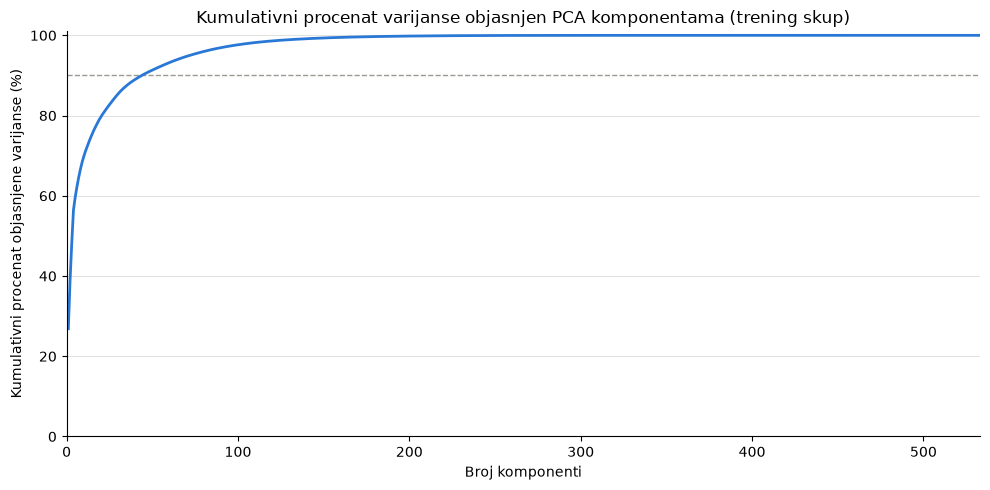

Broj komponenti koje objasnjavaju bar 90% varijanse: 44
  one zajedno objasnjavaju 90.04% varijanse
  redukcija dimenzije: 533 -> 44 atributa
  dimenzije posle redukcije:  (3584, 44) (896, 44)
Linearne kombinacije prve 3 komponente: 
PC1 (26.86% varijanse), 10 najvecih koeficijenata od ukupno 533:
  PC1 = +0.0711 * ECG_hrv_max
         -0.0710 * ECG_RR_window_prctile25
         +0.0707 * ECG_hrv_prctile75
         +0.0706 * ECG_HR_min_div_prctile75
         -0.0705 * ECG_RR_window_harmmean
         +0.0700 * ECG_HR_min_div_mean
         -0.0699 * ECG_RR_window_geomean(abs)
         -0.0698 * ECG_RR_window_median
         -0.0696 * ECG_RR_window_trimmean25
         +0.0696 * ECG_HR_min_div_trimmean25
         ... jos 523 clanova
  ovih 10 koeficijenata nosi 3.5% ukupnog zbira apsolutnih koeficijenata, dakle komponenta je razvucena preko velikog broja atributa
PC2 (11.92% varijanse), 10 najvecih koeficijenata od ukupno 533:
  PC2 = +0.1141 * IT_PSD_mean
         +0.1141 * IT_PSD_mad
    

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

VARIANCE_TARGET = 0.9
TOP_COMPONENTS = 3
TOP_LOADINGS = 10

# PCA nad globalno standardizovanim podacima. Prvo zadrzavamo sve komponente, da bismo videli kako se varijansa
# raspodeljuje po njima. PCA se uci samo na trening skupu (fit_transform), a test skup se samo projektuje na
# vec nadjene pravce (transform), da pravci komponenti ne bi nosili informaciju iz test skupa.
pca = PCA(n_components=None, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Broj zadrzanih komponenti: ", pca.n_components_)
print("Dimenzije posle PCA: ", X_train_pca.shape, X_test_pca.shape)
print("Procenat objasnjene varijanse za prvih 10 komponenti: ")
for i in range(10):
    print(f"  PC{i + 1:<3} {explained[i] * 100:6.2f}%   kumulativno {cumulative[i] * 100:6.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative * 100, color="#2a78d6", linewidth=2)
ax.axhline(VARIANCE_TARGET * 100, color="#9a9a94", linewidth=1, linestyle="--", zorder=0)
ax.set_xlabel("Broj komponenti")
ax.set_ylabel("Kumulativni procenat objasnjene varijanse (%)")
ax.set_title("Kumulativni procenat varijanse objasnjen PCA komponentama (trening skup)")
ax.set_xlim(0, len(cumulative))
ax.set_ylim(0, 101)
ax.grid(axis="y", color="#9a9a94", linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Izdvajamo najmanji broj komponenti koje zajedno objasnjavaju bar 90% varijanse. Komponente su vec sortirane
# po opadajucoj objasnjenoj varijansi, pa je dovoljno uzeti pocetni deo niza.
n_components_90 = int(np.searchsorted(cumulative, VARIANCE_TARGET) + 1)
X_train_pca_90 = X_train_pca[:, :n_components_90]
X_test_pca_90 = X_test_pca[:, :n_components_90]

print(f"Broj komponenti koje objasnjavaju bar {VARIANCE_TARGET * 100:.0f}% varijanse: {n_components_90}")
print(f"  one zajedno objasnjavaju {cumulative[n_components_90 - 1] * 100:.2f}% varijanse")
print(f"  redukcija dimenzije: {X_train_scaled.shape[1]} -> {n_components_90} atributa")
print("  dimenzije posle redukcije: ", X_train_pca_90.shape, X_test_pca_90.shape)

# Svaka komponenta je linearna kombinacija svih 533 standardizovana atributa, a koeficijenti su vrste matrice
# pca.components_. Vektor koeficijenata ima normu 1, pa koeficijent pokazuje koliko atribut ucestvuje u
# komponenti, dok znak govori u kom smeru (atributi suprotnog znaka se ponasaju suprotno unutar komponente).
components = pd.DataFrame(pca.components_, columns=X_train_scaled.columns)

print(f"Linearne kombinacije prve {TOP_COMPONENTS} komponente: ")
for i in range(TOP_COMPONENTS):
    coefficients = components.iloc[i]
    strongest = coefficients.abs().sort_values(ascending=False).index[:TOP_LOADINGS]
    share = float(coefficients[strongest].abs().sum() / coefficients.abs().sum())

    print(f"PC{i + 1} ({explained[i] * 100:.2f}% varijanse), "
          f"{TOP_LOADINGS} najvecih koeficijenata od ukupno {len(coefficients)}:")
    terms = [f"{coefficients[name]:+.4f} * {name}" for name in strongest]
    print(f"  PC{i + 1} = {terms[0]}")
    for term in terms[1:]:
        print(f"         {term}")
    print(f"         ... jos {len(coefficients) - TOP_LOADINGS} clanova")
    print(f"  ovih {TOP_LOADINGS} koeficijenata nosi {share * 100:.1f}% ukupnog zbira apsolutnih koeficijenata, "
          f"dakle komponenta je razvucena preko velikog broja atributa")


Prve 2 PCA komponente pokrivaju  38.78% objasnjene varijanse


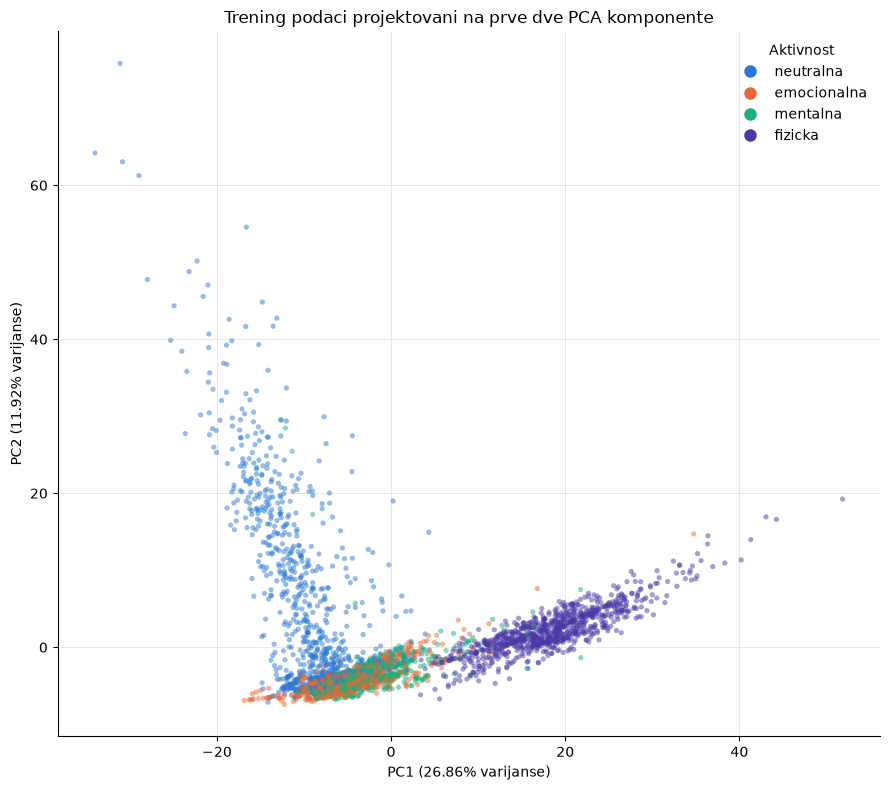

Centroidi klasa u ravni prve dve komponente: 
  neutralna    broj tacaka  896   PC1  -9.927   PC2  +6.028
  emocionalna  broj tacaka  896   PC1  -5.024   PC2  -4.389
  mentalna     broj tacaka  896   PC1  -3.300   PC2  -3.844
  fizicka      broj tacaka  896   PC1 +18.252   PC2  +2.205


In [5]:
from matplotlib.lines import Line2D

# izdvojeni PCA projektovani podaci sa top 2 komponente kako bi videli 2D vizualizaciju podataka
X_train_pca_top2 = X_train_pca[:, :2]
X_test_pca_top2 = X_test_pca[:, :2]
print(f"Prve 2 PCA komponente pokrivaju {cumulative[1] * 100:6.2f}% objasnjene varijanse")

ACTIVITY_NAMES = {1: "neutralna", 2: "emocionalna", 3: "mentalna", 4: "fizicka"}
ACTIVITY_PLOT_COLORS = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a", 4: "#4a3aa7"}

# Tacke crtamo u nasumicnom redosledu, da klasa koja bi se crtala poslednja ne bi prekrila ostale i tako
# lazno delovala brojnije. Providnost i sitni markeri se koriste zato sto se 3584 tacke dosta preklapaju.
shuffle_order = np.random.default_rng(RANDOM_STATE).permutation(len(X_train_pca_top2))
point_colors = y_train.map(ACTIVITY_PLOT_COLORS).to_numpy()

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(X_train_pca_top2[shuffle_order, 0], X_train_pca_top2[shuffle_order, 1],
           c=point_colors[shuffle_order], s=14, alpha=0.5, linewidths=0)

legend_handles = [Line2D([], [], marker="o", linestyle="none", markersize=8,
                         color=ACTIVITY_PLOT_COLORS[activity], label=ACTIVITY_NAMES[activity])
                  for activity in sorted(ACTIVITY_NAMES)]
ax.legend(handles=legend_handles, title="Aktivnost", frameon=False, loc="best")

ax.set_xlabel(f"PC1 ({explained[0] * 100:.2f}% varijanse)")
ax.set_ylabel(f"PC2 ({explained[1] * 100:.2f}% varijanse)")
ax.set_title("Trening podaci projektovani na prve dve PCA komponente")
ax.grid(color="#9a9a94", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Uz grafik ispisujemo i centroide klasa, da bi se videlo koliko se klase zaista razdvajaju u ovoj ravni,
# nezavisno od toga koliko se tacke na slici preklapaju.
print("Centroidi klasa u ravni prve dve komponente: ")
for activity in sorted(ACTIVITY_NAMES):
    mask = (y_train == activity).to_numpy()
    print(f"  {ACTIVITY_NAMES[activity]:<12} broj tacaka {int(mask.sum()):4d}"
          f"   PC1 {X_train_pca_top2[mask, 0].mean():+7.3f}   PC2 {X_train_pca_top2[mask, 1].mean():+7.3f}")
